In [ ]:
#coding comments in hashtags are by Ashley Hui

In [ ]:
#import stats-related, visualization, modeling, libraries and packages needed to processs data
#duck db is used to create a single database that holds all schemas, changes all in one go
#keeps it organized, cleaner and configures to all files automatically, will not fail if have different dataframas and file formats, etc

In [ ]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
import os

In [ ]:
#open up all data, show some summary statistics, and note abnormalities that show up in first runthrough

In [ ]:
db = duckdb.from_csv_auto('/Volumes/T7/IDX_data/CRMLSSold202506.csv').to_df()

In [ ]:
db

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,LotSizeDimensions,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict
0,SanDiego,SanDiego,None,False,<NA>,<NA>,False,5000.0,542181398,ops@downtowncondoguys.com,...,None,NaN,NaN,<NA>,1.0,None,92101,0.0,NaN,None
1,PacificWest,PacificWest,None,True,<NA>,<NA>,<NA>,110000.0,540760713,nowjoanne@gmail.com,...,None,355936.0,NaN,False,NaN,None,93550,0.0,355936.0,None
2,SouthwestLosAngeles,SouthwestLosAngeles,None,True,<NA>,<NA>,<NA>,1545000.0,525608302,Austin_Brown@pacificplayarealty.com,...,88x231,20212.0,NaN,False,NaN,None,90008,NaN,20212.0,None
3,TheInlandGateway,TheInlandGateway,None,True,<NA>,<NA>,False,889000.0,523319952,hutton@cbappteam.com,...,None,9600.0,0.0,True,2.0,Rim of the World,92352,0.0,9600.0,None
4,SanDiego,SanDiego,Laminate,True,<NA>,<NA>,False,1700.0,518730969,mannybehar@yahoo.com,...,None,NaN,NaN,<NA>,0.0,None,92126,0.0,NaN,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22878,Mlslistings,Mlslistings,None,False,<NA>,<NA>,<NA>,36900000.0,1019048995,btanger@intero.com,...,None,515314.8,NaN,<NA>,NaN,Other,95070,NaN,515314.8,None
22879,WestSanGabrielValley,WestSanGabrielValley,None,True,<NA>,<NA>,True,9180000.0,1018931071,sostlund@lee-assoc.com,...,None,174240.0,5.0,False,4.0,Capistrano Unified,92679,695.0,174240.0,None
22880,Mlslistings,Mlslistings,None,False,<NA>,<NA>,<NA>,349000.0,1016273554,sara@coastalcahomes.com,...,None,138521.0,NaN,<NA>,NaN,Other,93907,214.0,138521.0,None
22881,OrangeCounty,OrangeCounty,"Stone,Wood",True,<NA>,<NA>,False,17000.0,1014281750,Leeann@canadaygroup.com,...,None,5950.0,1.0,False,2.0,Laguna Beach Unified,92651,0.0,5950.0,None


In [ ]:
db.describe()

,OriginalListPrice,ListingKey,CloseDate,ClosePrice,Latitude,Longitude,LivingArea,ListPrice,DaysOnMarket,ListingKeyNumeric,...,ContractStatusChangeDate,PurchaseContractDate,ListingContractDate,BelowGradeFinishedArea,Stories,LotSizeArea,MainLevelBedrooms,GarageSpaces,AssociationFee,LotSizeSquareFeet
count,2.281100e+04,2.288300e+04,22883,2.288300e+04,22879.000000,22880.000000,21308.000000,2.284800e+04,22883.000000,2.288300e+04,...,22883,22443,22882,110.000000,18732.00000,2.106300e+04,12364.000000,19916.000000,15665.000000,2.104100e+04
mean,8.973742e+05,1.109938e+09,2025-06-15 05:17:54.981427,8.922487e+05,34.548733,-118.458038,1825.190867,8.619410e+05,41.476992,1.109938e+09,...,2025-06-15 05:17:54.981427,2025-05-19 17:36:26.178318,2025-04-01 02:50:59.103225,55.609091,1.37177,5.234909e+04,1.902378,1.778721,177.400540,4.638715e+05
min,0.000000e+00,4.218253e+08,2025-06-01 00:00:00,0.000000e+00,0.000000,-156.450320,0.000000,1.400000e+00,-26.000000,4.218253e+08,...,2025-06-01 00:00:00,2021-07-25 00:00:00,2015-05-15 00:00:00,0.000000,1.00000,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00
25%,4.750000e+04,1.109110e+09,2025-06-09 00:00:00,4.000000e+04,33.733862,-118.561905,1184.000000,4.737500e+04,9.000000,1.109110e+09,...,2025-06-09 00:00:00,2025-05-09 00:00:00,2025-03-19 00:00:00,0.000000,1.00000,5.009500e+03,1.000000,1.000000,0.000000,5.227000e+03
50%,6.490000e+05,1.112153e+09,2025-06-16 00:00:00,6.315000e+05,34.041916,-118.055588,1595.000000,6.380000e+05,22.000000,1.112153e+09,...,2025-06-16 00:00:00,2025-05-22 00:00:00,2025-04-22 00:00:00,0.000000,1.00000,7.207000e+03,2.000000,2.000000,0.000000,7.405000e+03
75%,1.100000e+06,1.113861e+09,2025-06-23 00:00:00,1.100000e+06,34.393690,-117.330082,2185.250000,1.099000e+06,50.000000,1.113861e+09,...,2025-06-23 00:00:00,2025-06-04 00:00:00,2025-05-12 00:00:00,0.000000,2.00000,1.219700e+04,3.000000,2.000000,283.000000,1.361100e+04
max,2.395000e+08,1.118608e+09,2025-06-30 00:00:00,9.000000e+08,45.772309,121.116478,39111.000000,6.800000e+07,1265.000000,1.118608e+09,...,2025-06-30 00:00:00,2025-06-30 00:00:00,2025-06-30 00:00:00,2000.000000,2.00000,2.831400e+08,34.000000,500.000000,8063.000000,2.090880e+09
std,2.331296e+06,1.438173e+07,NaN,6.084893e+06,1.651760,3.917697,1164.276153,1.394472e+06,62.518260,1.438173e+07,...,NaN,NaN,NaN,252.155300,0.48329,2.020131e+06,1.435027,4.649280,340.986858,2.056782e+07


Key features:
- ListingKey is ID
- Target? OriginalListPrice or ListPrice or ClosePrice?

Issues:
- NaN values coded inconsistent
- Possible invalid values in ParkingTotal, DaysOnMarket
- ListPrice not available for 35 houses (drop or impute?)

Notes: PropertyType="Residential" and PropertySubType="SingleFamilyResidence"

In [ ]:
db['PropertyType'].value_counts()

PropertyType
Residential            15329
ResidentialLease        5376
Land                     706
ManufacturedInPark       638
ResidentialIncome        571
CommercialSale           135
CommercialLease          112
BusinessOpportunity       16
Name: count, dtype: int64

# Data Ingestion

Confirmed alignment and uniqueness of key

# Missing values identification

## Populate DB with all training data

In [ ]:
#take data from last 6 months of property sales to be used as training data for model as instructed

In [ ]:
training_months = range(6, 13)
conn = None
conn = duckdb.connect('CRMLS.db')
path = '../IDX_data/'
files = [f for f in os.listdir(path) if not f.startswith('.')]

conn.query(
    f"""
    CREATE TABLE IF NOT EXISTS Property AS
    SELECT
        * EXCLUDE (filename),
        strptime(regexp_extract(filename, 'CRMLSSold(\\d{{6}})\\.csv$', 1), '%Y%m')::DATE AS ReadDate
    FROM read_csv_auto('../IDX_data/{files[0]}', filename = True, nullstr = ['NaN','nan','N/A','NA','', 'NULL'])
    """
)

for n in range(1, len(files)):
    conn.query(
        f"""
    INSERT INTO Property
    SELECT
        * EXCLUDE (filename),
        strptime(regexp_extract(filename, 'CRMLSSold(\\d{{6}})\\.csv$', 1), '%Y%m')::DATE AS ReadDate
    FROM read_csv_auto('../IDX_data/{files[n]}', filename = True, nullstr = ['NaN','nan','N/A','NA','', 'NULL'])
    """
    )


In [ ]:
db = conn.table("Property")
(db
 .filter(
    """
        PropertyType = 'Residential'
        AND PropertySubType = 'SingleFamilyResidence'
        AND ClosePrice > 0
        AND LivingArea > 0
        AND Latitude IS NOT NULL
        AND Longitude IS NOT NULL
        AND Latitude BETWEEN 32 AND 43
        AND Longitude BETWEEN -125 AND -113
    """)
 .select()
 .aggregate("count(ListingId)")
 ).fetchdf()


,count(ListingId)
0,280934


In [ ]:
conn.query(
    """
    SELECT count(ListingId) FROM Property
        WHERE
            PropertyType = 'Residential' AND
            PropertySubType = 'SingleFamilyResidence'
    """
)

┌──────────────────┐
│ count(ListingId) │
│      int64       │
├──────────────────┤
│           280934 │
└──────────────────┘

In [ ]:
#check out missing rates in columns, display how much % is missing to see which columns can be filled in (imputated), fixed or dropped all togther
#to help clean the data

In [ ]:
def column_na_plot(df: pd.DataFrame):
    is_na = []
    data = df.copy()
    for column in data.columns:
        is_na_perc = data[column].isna().sum() * 100 / len(data[column])
        if is_na_perc > 0:
            is_na.append( is_na_perc )
        else:
            data.drop(column, axis=1, inplace=True)
    plt.figure(figsize = (20,10))
    plt.bar(x=data.columns, height=is_na)
    plt.xticks(rotation=90)
    plt.xlabel('Columns')
    plt.ylabel('% Missing Values')
    plt.title('Percentage of Missing Values in each column')
    plt.show()

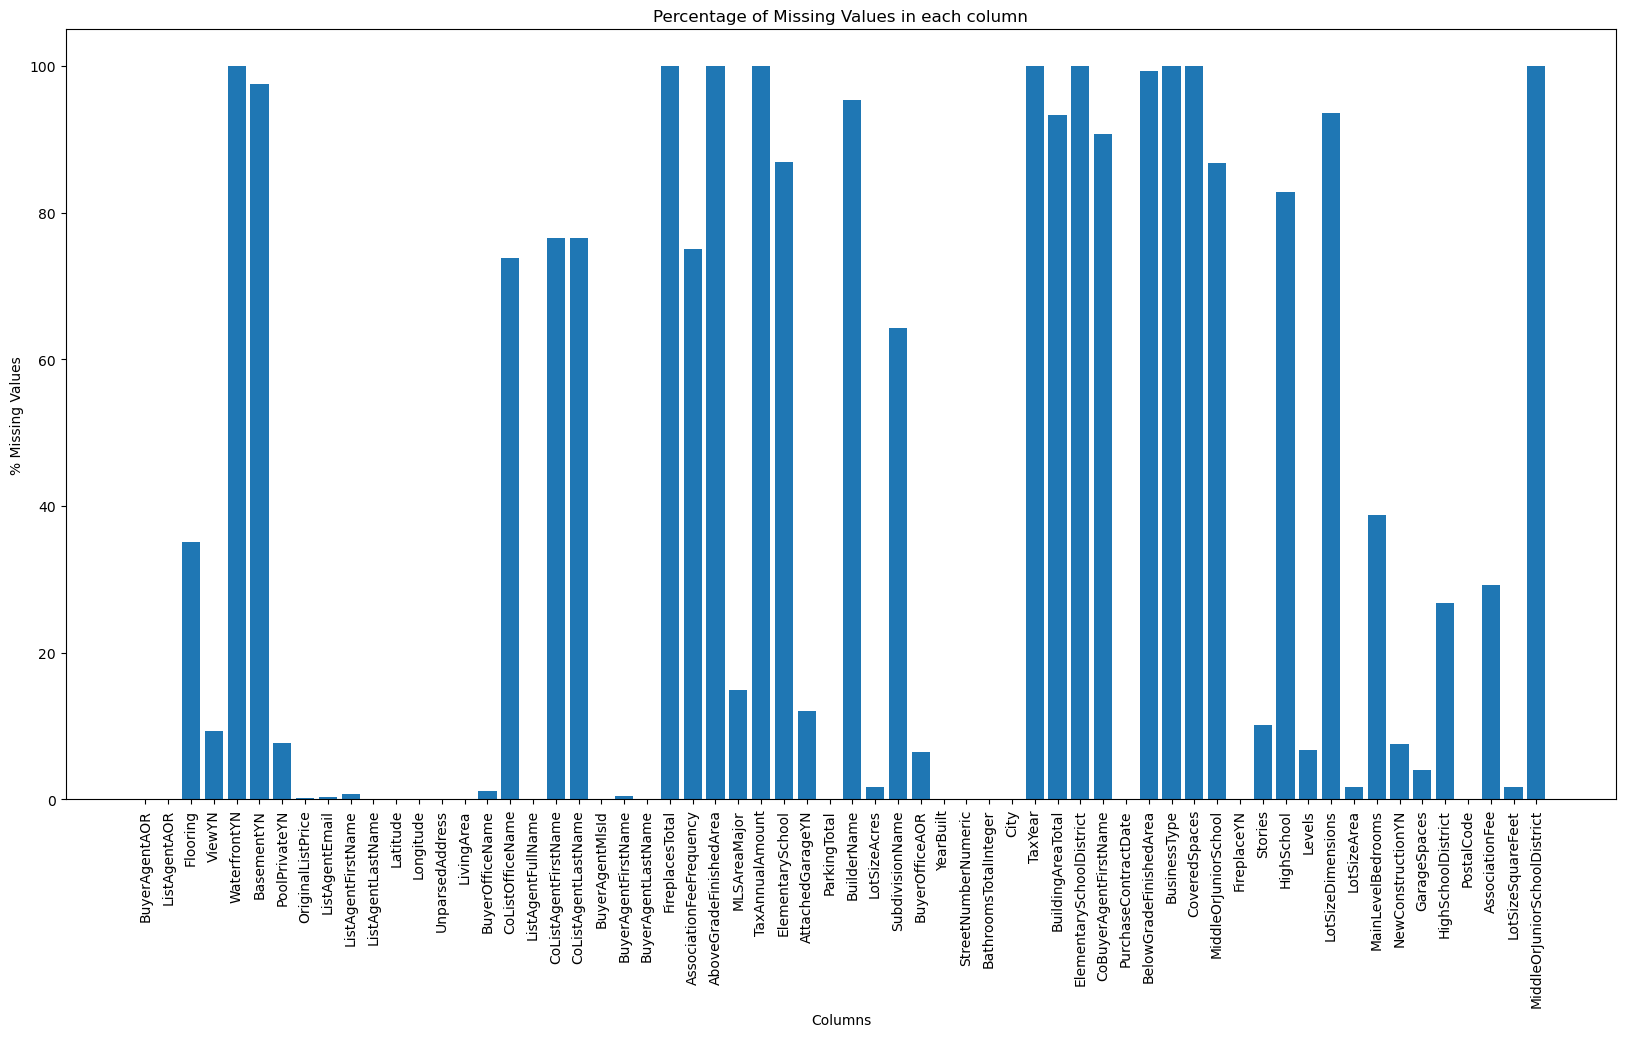

In [ ]:
def reset_df():
    conn = duckdb.connect('CRMLS.db')
    df = conn.query(
        """
        SELECT *
        FROM Property
        WHERE
            PropertyType = 'Residential' AND
            PropertySubType = 'SingleFamilyResidence'
        """
    ).to_df(date_as_object=False)
    df.set_index(['ListingId', 'ReadDate'], inplace=True)
    df.drop_duplicates(inplace=True)
    # df.set_index(['ListingId', 'ReadDate'], inplace=True)
    return df

df = reset_df()

column_na_plot(df)

For columns with > 50% NaNs, dropping the whole columns

In [ ]:
na_columns = df.columns[df.isna().sum() > 0].tolist()
print(na_columns)

['BuyerAgentAOR', 'ListAgentAOR', 'Flooring', 'ViewYN', 'WaterfrontYN', 'BasementYN', 'PoolPrivateYN', 'OriginalListPrice', 'ListAgentEmail', 'ListAgentFirstName', 'ListAgentLastName', 'Latitude', 'Longitude', 'UnparsedAddress', 'LivingArea', 'BuyerOfficeName', 'CoListOfficeName', 'ListAgentFullName', 'CoListAgentFirstName', 'CoListAgentLastName', 'BuyerAgentMlsId', 'BuyerAgentFirstName', 'BuyerAgentLastName', 'FireplacesTotal', 'AssociationFeeFrequency', 'AboveGradeFinishedArea', 'MLSAreaMajor', 'TaxAnnualAmount', 'ElementarySchool', 'AttachedGarageYN', 'ParkingTotal', 'BuilderName', 'LotSizeAcres', 'SubdivisionName', 'BuyerOfficeAOR', 'YearBuilt', 'StreetNumberNumeric', 'BathroomsTotalInteger', 'City', 'TaxYear', 'BuildingAreaTotal', 'ElementarySchoolDistrict', 'CoBuyerAgentFirstName', 'PurchaseContractDate', 'BelowGradeFinishedArea', 'BusinessType', 'CoveredSpaces', 'MiddleOrJuniorSchool', 'FireplaceYN', 'Stories', 'HighSchool', 'Levels', 'LotSizeDimensions', 'LotSizeArea', 'MainLev

## Check importance of remaining columns with NaNs

- Listing agent's name parts will be dropped and Id will be utilized to remove redundancy. However, need to compare predictive power to ListAgenAOR to see if it is needed to go in details.
- BuyerAgents information will be discarded as we can't judge people behavior based on their name.
- MainLevelBedroom is dropped due to redundancy and high missingness
- AssociationFees can be imputed with 0 to indicate the property doesn't have HOA fees.
- Drop ListingPrice and OriginalListingPrice per instructions from Aidan
- Drop ListingId fields to reduce overfit.
- Drop MLSStatus as it only contain Closed status
- Drop ListingContractDate and ContractChangeDate as the focus is in close price and DaysOnMarket already contain the necessary info.
- Drop all geographic features to remove redundancy to ZIP code


In [ ]:
df = reset_df()
higher_than_50_na = [col for col in df.columns if (df[col].isna().sum() * 100 / df.shape[0]) > 50]
df.drop(columns=higher_than_50_na, axis=1, inplace=True)
df = df[((df['ClosePrice'] > 0) & (df['Longitude'].notnull()) & (df['Latitude'].notnull())) & (df['LivingArea'] > 0)]
for column in df.columns:
    if ("uyer" in column) or ("Name" in column):
        df.drop(column, axis=1, inplace=True)
df.drop(['MainLevelBedrooms', 'AssociationFee', 'ListPrice', 'OriginalListPrice', 'PropertyType', 'PropertySubType', 'ListingKey', 'ListingKeyNumeric', 'PurchaseContractDate', 'MlsStatus', 'UnparsedAddress', 'StreetNumberNumeric', 'City', 'StateOrProvince'], axis=1, inplace=True)
df.drop(['HighSchoolDistrict', 'MLSAreaMajor', 'Flooring', 'Stories', 'ListAgentEmail', 'ContractStatusChangeDate', 'ListingContractDate'], axis=1, inplace=True)
# df = df[df['ClosePrice'].between(df['ClosePrice'].quantile(0.5), df['ClosePrice'].quantile(0.95))]

df['log_price'] = np.log(df['ClosePrice'])

In [ ]:
df.columns

Index(['ListAgentAOR', 'ViewYN', 'PoolPrivateYN', 'CloseDate', 'ClosePrice',
       'Latitude', 'Longitude', 'LivingArea', 'DaysOnMarket', 'CountyOrParish',
       'AttachedGarageYN', 'ParkingTotal', 'LotSizeAcres', 'YearBuilt',
       'BathroomsTotalInteger', 'BedroomsTotal', 'FireplaceYN', 'Levels',
       'LotSizeArea', 'NewConstructionYN', 'GarageSpaces', 'PostalCode',
       'LotSizeSquareFeet', 'log_price'],
      dtype='object')

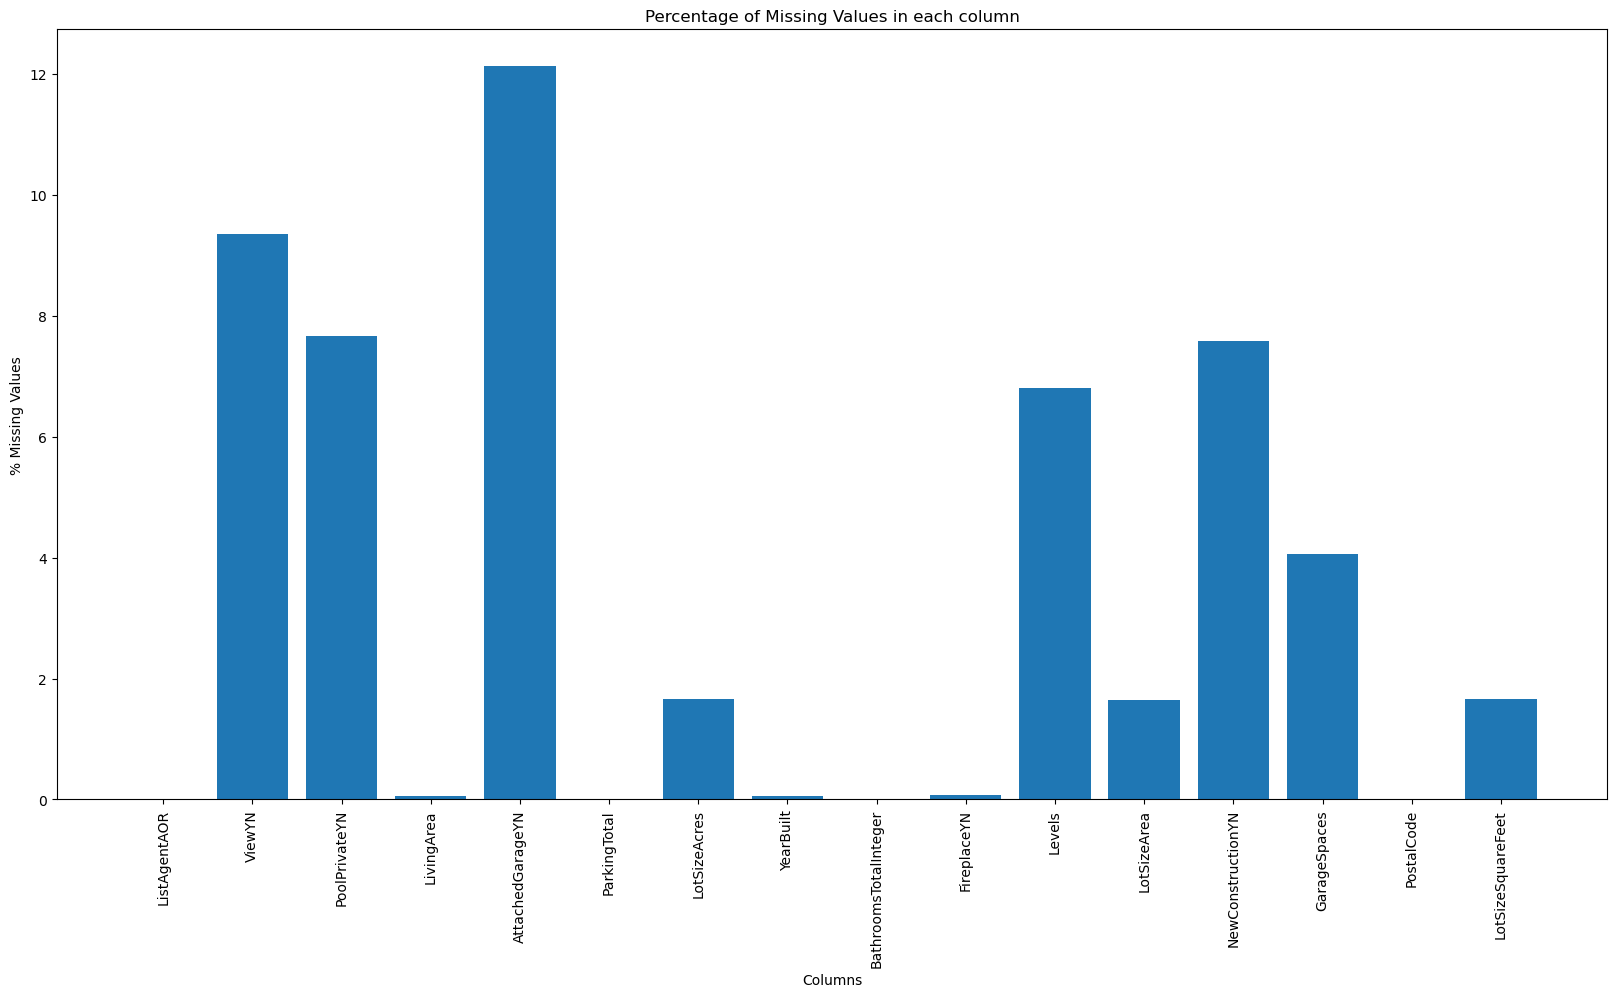

In [ ]:
column_na_plot(df)

Questions:
- Is Listing agents info necessary?
- Does Zipcode alone sufficient to carry geographic info of the property or City + County + State (cannot encode quickly due to non-ordinal nature)?
- Is None in District mean property not in a school district? It has low availability, drop it?
- Should we use ContractListingDate as listing date? Is it necessary? (encode by cyclical feature)
- Should we use external inflation data?

Must imputation:
- LotSizeArea, LotSizeSquareFeet

Potential imputation:
- Levels / Stories

# Feature Engineering

In [ ]:
#cleaning up and imputing zip codes in data as it's needed for model, it does affect prices depending on location

In [ ]:
def zipcode_parse(org: str):
    if org is not None:
        if len(org) >= 5:
            return org[:5]
        else:
            return 0
    else:
        return 0

df['PostalCode'] = df['PostalCode'].apply(zipcode_parse)

In [ ]:
df.describe()

,CloseDate,ClosePrice,Latitude,Longitude,LivingArea,DaysOnMarket,ParkingTotal,LotSizeAcres,YearBuilt,BathroomsTotalInteger,BedroomsTotal,LotSizeArea,GarageSpaces,LotSizeSquareFeet,log_price
count,78943,7.894300e+04,78937.000000,78937.000000,78900.000000,78943.000000,78942.000000,77636.000000,78897.000000,78932.000000,78943.000000,7.764400e+04,75744.000000,7.763400e+04,7.894300e+04
mean,2025-09-12 02:03:16.364465,1.330039e+06,34.745145,-118.615232,2042.034419,40.387571,2.915983,17.896793,1975.459472,2.622764,3.491203,1.700242e+04,2.005538,4.154659e+05,-inf
min,2025-06-01 00:00:00,0.000000e+00,0.000000,-124.193201,0.000000,-265.000000,-12.000000,0.000000,1776.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,-inf
25%,2025-07-22 00:00:00,6.250000e+05,33.768487,-119.164032,1384.000000,9.000000,2.000000,0.130000,1955.000000,2.000000,3.000000,5.429000e+03,2.000000,5.663000e+03,1.334551e+01
50%,2025-09-12 00:00:00,8.850000e+05,34.088241,-118.038944,1813.000000,22.000000,2.000000,0.167500,1976.000000,2.000000,3.000000,7.114500e+03,2.000000,7.295000e+03,1.369334e+01
75%,2025-11-03 00:00:00,1.400000e+06,34.852347,-117.267419,2429.000000,54.000000,3.000000,0.240000,1998.000000,3.000000,4.000000,1.000000e+04,2.000000,1.045400e+04,1.415198e+01
max,2025-12-31 00:00:00,9.895000e+08,43.784440,120.432670,56500.000000,894.000000,1111.000000,127631.000000,2026.000000,35.000000,19.000000,1.307236e+07,500.000000,1.938943e+09,2.071271e+01
std,NaN,8.428193e+06,1.727021,3.246931,1050.282115,50.249267,9.659813,944.281999,27.562474,1.126060,0.961613,1.059590e+05,3.312124,1.763652e+07,NaN


In [ ]:
#cyclical encoding is needed to make sure model knows that time is not a purely linear and there is no strict cutoff between time/months
#give better predictions on time‑related (like by month) effects

In [ ]:
def cyclical_encoding(x):
    return np.sin(2 * np.pi * (x.month/12.0))

df['engineered_closed_date'] = df['CloseDate'].apply(cyclical_encoding)


# Imputation

Prepare imputation for base model

In [ ]:
#imputated data into some columns, dropped some as well and standardized to prepare data to be fed into model
#trimmed the 0.5% of data as well

In [ ]:
print(f'Mean: {df['ClosePrice'].mean()}')
print(f'Stdev: {df['ClosePrice'].std()}')

Mean: 1326501.7594527218
Stdev: 8430110.944962751


In [ ]:
from scipy.stats import norm

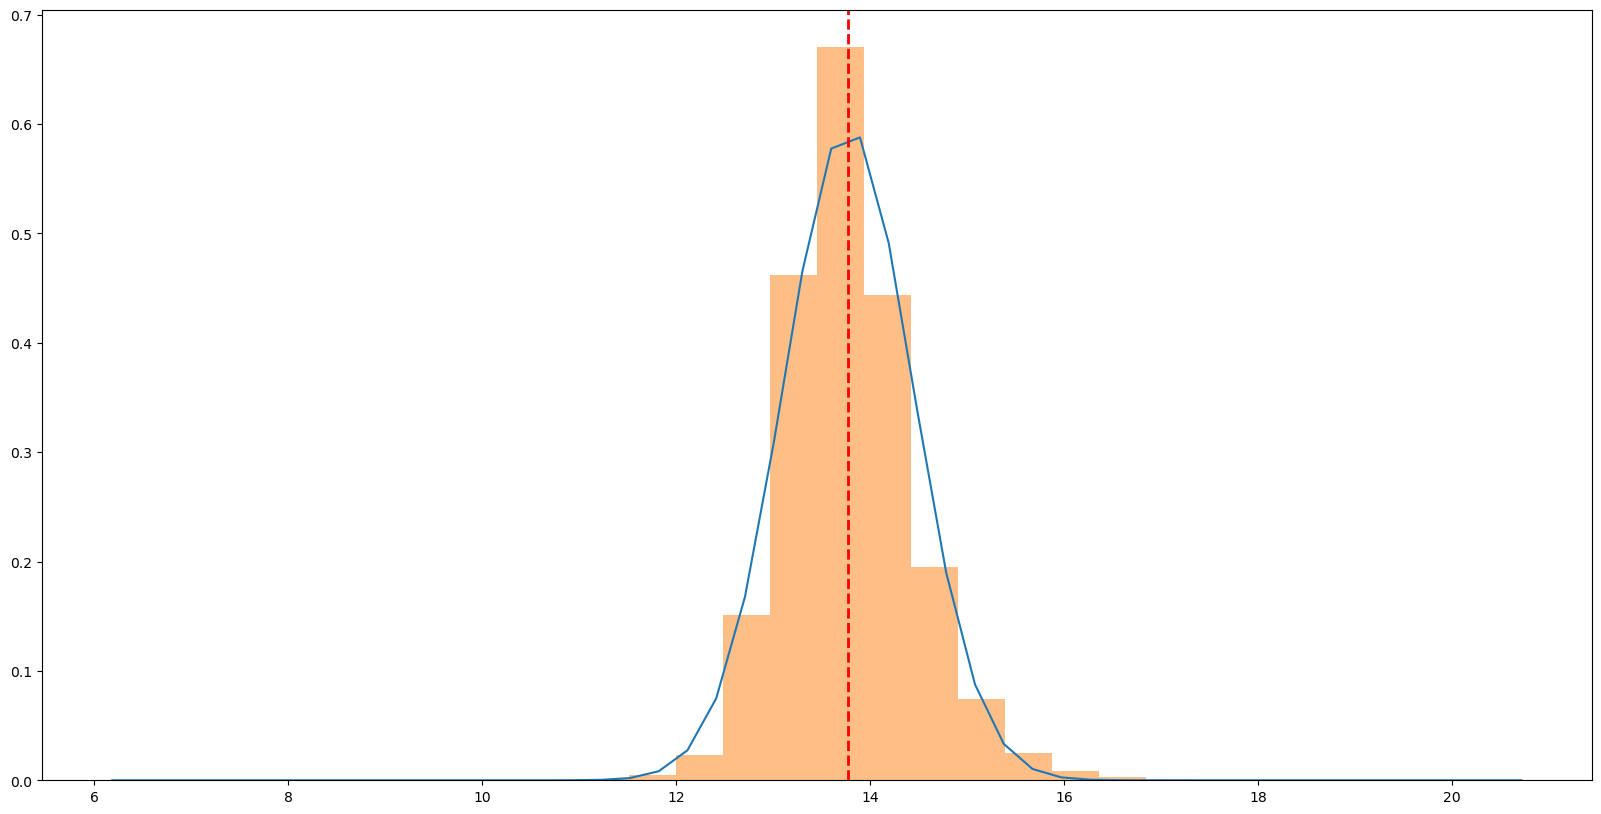

In [ ]:
# Log price
# logged_price = np.log(df['ClosePrice'])
logged_price = df['log_price']

fig = plt.figure(figsize = (20,10))
domain = np.linspace(np.min(logged_price), np.max(logged_price))
mu, sigma = np.mean(logged_price), np.std(logged_price, ddof=1)
normal_curve = norm.pdf(domain, mu, sigma)
plt.plot(domain, normal_curve, label='Normal')
plt.hist(logged_price, bins=30, label='Normal', alpha=0.5, density=True)
plt.axvline(x=mu, color='r', linestyle='dashed', linewidth=2)


plt.show()

ClosePrice is Normal after logged

In [ ]:
df_tmp = df.reset_index().reset_index()
# df_tmp['ListingId'].value_counts()
df_tmp.drop(columns=['ListingId'], axis=1, inplace=True)

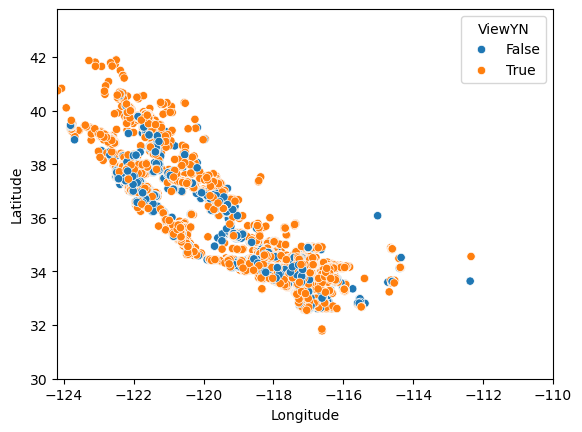

In [ ]:
sns.scatterplot(
    data=df[df['ViewYN'].notnull()],
    x='Longitude',
    y='Latitude',
    hue='ViewYN',
)
plt.xlim(np.min(df['Longitude']), -110)
plt.ylim(30, np.max(df['Latitude']))

plt.show()

In [ ]:
df

,,ListAgentAOR,ViewYN,PoolPrivateYN,CloseDate,ClosePrice,Latitude,Longitude,LivingArea,DaysOnMarket,CountyOrParish,...,BedroomsTotal,FireplaceYN,Levels,LotSizeArea,NewConstructionYN,GarageSpaces,PostalCode,LotSizeSquareFeet,log_price,engineered_closed_date
ListingId,ReadDate,,,,,,,,,,,,,,,,,,,,,
EV21134678,2025-06-01,TheInlandGateway,True,False,2025-06-13,890000.0,34.264692,-117.221040,3000.0,181,San Bernardino,...,3.0,True,Two,9600.0,True,2.0,92352,9600.0,13.698977,1.224647e-16
25559373,2025-06-01,BeverlyHillsGreaterLa,True,False,2025-06-30,1876384.0,34.107983,-118.390320,1800.0,87,Los Angeles,...,3.0,True,Two,10400.0,False,NaN,90046,10400.0,14.444857,1.224647e-16
ML82012939,2025-06-01,Mlslistings,False,<NA>,2025-06-30,4820000.0,37.567434,-122.388226,4270.0,0,San Mateo,...,6.0,True,None,22505.0,False,3.0,94010,22505.0,15.388284,1.224647e-16
PW25146750,2025-06-01,PacificWest,True,False,2025-06-30,865000.0,33.906058,-117.777782,1442.0,0,Orange,...,3.0,True,One,4800.0,False,2.0,92886,4800.0,13.670485,1.224647e-16
41103262,2025-06-01,BayEast,<NA>,False,2025-06-30,875000.0,37.705919,-122.059421,1086.0,0,Alameda,...,3.0,True,One,5500.0,False,4.0,94546,5500.0,13.681979,1.224647e-16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GD23212467,2025-12-01,Glendale,True,False,2025-12-05,640000.0,34.608952,-118.259648,2474.0,171,Los Angeles,...,3.0,True,One,105281.0,False,3.0,93551,105281.0,13.369223,-2.449294e-16
ML81923705,2025-12-01,Mlslistings,True,<NA>,2025-12-04,12000000.0,37.443497,-122.150296,5353.0,755,Santa Clara,...,5.0,True,None,15118.0,False,2.0,94301,15118.0,16.300417,-2.449294e-16
NS23056449,2025-12-01,NorthSanLuisObispo,True,False,2025-12-17,600000.0,35.903719,-120.982965,2038.0,894,Monterey,...,3.0,True,One,20.0,False,0.0,93426,871200.0,13.304685,-2.449294e-16


In [ ]:
base_df = df_tmp[[column for column in df.columns if df[column].isna().sum() == 0]]
base_df

,CloseDate,ClosePrice,Latitude,Longitude,LivingArea,DaysOnMarket,CountyOrParish,BedroomsTotal,PostalCode,log_price,engineered_closed_date
0,2025-06-13,890000.0,34.264692,-117.221040,3000.0,181,San Bernardino,3.0,92352,13.698977,1.224647e-16
1,2025-06-30,1876384.0,34.107983,-118.390320,1800.0,87,Los Angeles,3.0,90046,14.444857,1.224647e-16
2,2025-06-30,4820000.0,37.567434,-122.388226,4270.0,0,San Mateo,6.0,94010,15.388284,1.224647e-16
3,2025-06-30,865000.0,33.906058,-117.777782,1442.0,0,Orange,3.0,92886,13.670485,1.224647e-16
4,2025-06-30,875000.0,37.705919,-122.059421,1086.0,0,Alameda,3.0,94546,13.681979,1.224647e-16
...,...,...,...,...,...,...,...,...,...,...,...
78858,2025-12-05,640000.0,34.608952,-118.259648,2474.0,171,Los Angeles,3.0,93551,13.369223,-2.449294e-16
78859,2025-12-04,12000000.0,37.443497,-122.150296,5353.0,755,Santa Clara,5.0,94301,16.300417,-2.449294e-16
78860,2025-12-17,600000.0,35.903719,-120.982965,2038.0,894,Monterey,3.0,93426,13.304685,-2.449294e-16
78861,2025-12-15,380000.0,34.261375,-117.211842,1452.0,38,San Bernardino,3.0,92352,12.847927,-2.449294e-16


In [ ]:
# fig = plt.figure(figsize = (7,10))
# sns.barplot(data=base_df['CountyOrParish'].value_counts(), orient='h')
# # plt.xticks(rotation=90)
# plt.show()

In [ ]:
# base_df = pd.get_dummies(base_df, columns=['CountyOrParish'], dtype=int)

In [ ]:
y = base_df['log_price']
base_df.drop(columns=['log_price', 'ClosePrice', 'PostalCode', 'CountyOrParish', 'CloseDate'], axis=1, inplace=True)
base_df

/tmp/ipykernel_23792/1206377031.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  base_df.drop(columns=['log_price', 'ClosePrice', 'PostalCode', 'CountyOrParish', 'CloseDate'], axis=1, inplace=True)


,Latitude,Longitude,LivingArea,DaysOnMarket,BedroomsTotal,engineered_closed_date
0,34.264692,-117.221040,3000.0,181,3.0,1.224647e-16
1,34.107983,-118.390320,1800.0,87,3.0,1.224647e-16
2,37.567434,-122.388226,4270.0,0,6.0,1.224647e-16
3,33.906058,-117.777782,1442.0,0,3.0,1.224647e-16
4,37.705919,-122.059421,1086.0,0,3.0,1.224647e-16
...,...,...,...,...,...,...
78858,34.608952,-118.259648,2474.0,171,3.0,-2.449294e-16
78859,37.443497,-122.150296,5353.0,755,5.0,-2.449294e-16
78860,35.903719,-120.982965,2038.0,894,3.0,-2.449294e-16
78861,34.261375,-117.211842,1452.0,38,3.0,-2.449294e-16


In [ ]:
def trimming_quantiles(X, y, quantile=0.05):
        if not (0 <= quantile < 0.5):
            raise ValueError("quantile must be in [0, 0.5)")

        lo, hi = y.quantile([quantile, 1 - quantile])
        mask = (y >= lo) & (y <= hi)
        return X.loc[mask], y.loc[mask]

def train_test_split_with_trimming(df, y, test_size=0.2, random_state=42):
    X_train, X_test, y_train, y_test = train_test_split(df, y, test_size=test_size, random_state=random_state)
    X_train, y_train = trimming_quantiles(X_train, y_train)
    X_test, y_test = trimming_quantiles(X_test, y_test)
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = train_test_split_with_trimming(base_df, y, test_size=0.2, random_state=42)


# Linear Regression

In [ ]:
#check if linear regression models be used to help predict close prices

In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)
model.score(X_test, y_test)

0.2416705280301764

In [ ]:
y_predicted = model.predict(X_test)
error = np.pow((y_predicted - y_test), 2)

In [ ]:
# begin - Johnny Lin

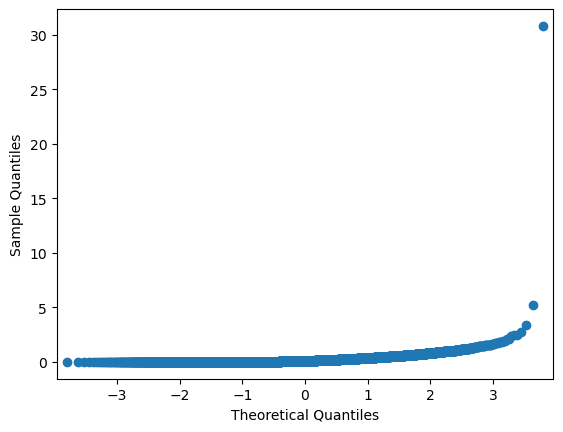

In [ ]:
from statsmodels.graphics.gofplots import qqplot

qqplot(error, ax=plt.gca())
plt.show()

## Conclusion

- Error not normally distributed. Cannot proceed with Linear Regression

In [ ]:
# end - Johnny Lin

In [ ]:
# begin - Eddie Nguyen

# XGBoost (Eddie Nguyen)

To avoid normal error assumption, I used Smearing factor from: https://people.stat.sc.edu/hoyen/PastTeaching/STAT704-2022/Notes/Smearing.pdf when transforming logged price back to its original scale

In [ ]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor()
model.fit(X_train, y_train)
y_predicted = model.predict(X_test)
model.score(X_test, y_test)

0.8873711456224866

In [ ]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_squared_error')

In [ ]:
scores = np.exp(y_predicted - y_test)
smearing = np.mean(scores)
original_scaled_y_hat = smearing * np.exp(y_predicted)

In [ ]:
original_scaled_y = np.exp(y_test)
error = original_scaled_y_hat - original_scaled_y

In [ ]:
mae = np.mean(np.abs(error))
rmse = np.sqrt(np.mean(error**2))   # RMSE = sqrt(MSE)
mse = np.mean(error**2)


In [ ]:
print(f'MAE: {mae:.2f}, RMSE: {rmse:.2f}, MSE: {mse:.2f}')

MAE: 133592.24, RMSE: 213374.07, MSE: 45528493620.91


By using non-NA features and encoded county information, I achieved a model that can predict with R2 = 0.887 and average RMSE of 213,374$

<Axes: xlabel='log_price', ylabel='Count'>

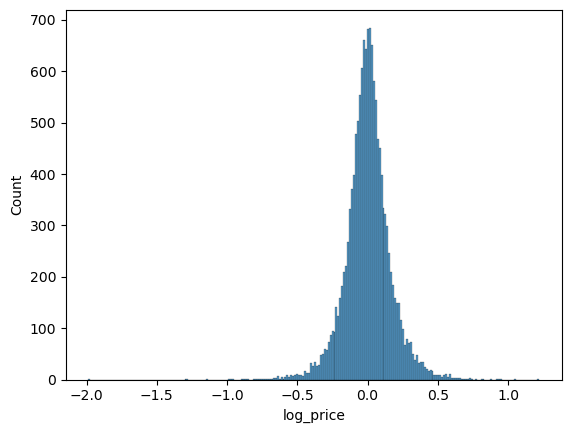

In [ ]:
residuals = y_predicted - y_test
abs_residuals = np.abs(residuals)
mdape = np.mean(abs_residuals / (y_test * 100))
sns.histplot(data=residuals)


<Axes: xlabel='log_price', ylabel='log_price'>

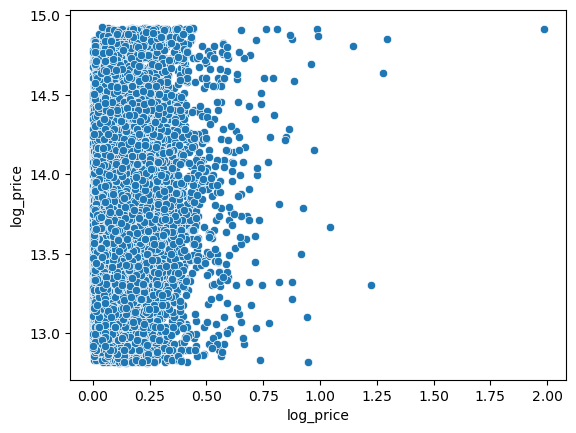

In [ ]:
sns.scatterplot(x=abs_residuals, y=y_test)

In [ ]:
print(mdape)

8.472164047975887e-05


In [ ]:
# end - Eddie Nguyen

In [ ]:
# begin - Jenny Li

# Close Price Engineering (Jenny Li)


In [ ]:
#creating new path
#then new ingestion object to insert raw data to create dataframe to do preprocessing

In [ ]:
from src.Preprocessing import get_unprocessed_data
from src.Ingestion import DataIngestion

In [ ]:
df.shape

(225096, 45)

In [ ]:
accessor.query("""SELECT * FROM Property LIMIT 10""")

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,ReadDate
0,TriCounties,TriCounties,None,True,<NA>,<NA>,<NA>,20000.0,519281718,myagentjosephine@gmail.com,...,2.50,NaN,False,NaN,None,93560,0.0,108900.0,None,2025-09-01
1,HighDesert,HighDesert,None,True,<NA>,<NA>,<NA>,120000.0,508553099,lrethier@aol.com,...,653400.00,NaN,False,NaN,None,92344,NaN,653400.0,None,2025-09-01
2,PacificWest,PacificWest,None,True,<NA>,<NA>,<NA>,299900.0,448373180,ocrealtorsteph@gmail.com,...,20.00,NaN,False,NaN,None,92595,0.0,871200.0,None,2025-09-01
3,SanDiego,SanDiego,None,True,<NA>,<NA>,False,3775000.0,1137354161,Sanjay.Solomon@compass.com,...,NaN,NaN,False,3.0,None,92037,NaN,NaN,None,2025-09-01
4,NorthSanDiegoCounty,NorthSanDiegoCounty,None,False,<NA>,<NA>,False,185000.0,1137353088,sharonjenkins4realestate@gmail.com,...,0.67,1.0,<NA>,0.0,San Marcos Unified,92078,2554.0,29185.2,None,2025-09-01
5,TheInlandGateway,TheInlandGateway,None,True,<NA>,<NA>,True,822000.0,1137349439,annb@loislauer.com,...,14560.00,5.0,False,2.0,Redlands Unified,92373,0.0,14560.0,None,2025-09-01
6,OrangeCounty,OrangeCounty,"Carpet,Vinyl,Wood",True,<NA>,<NA>,False,1575000.0,1137346577,Judy@JudyMcCartyRealty.com,...,3300.00,0.0,False,2.0,Saddleback Valley Unified,92630,255.0,3300.0,None,2025-09-01
7,SouthBay,SouthBay,None,True,<NA>,<NA>,False,3350000.0,1137309626,colin@colinaita.com,...,NaN,3.0,True,2.0,Hermosa,90254,0.0,NaN,None,2025-09-01
8,BeverlyHillsGreaterLa,BeverlyHillsGreaterLa,"Stone,Tile,Wood",True,<NA>,<NA>,<NA>,8022333.0,1137284778,bba@theagencyre.com,...,26981.00,NaN,False,NaN,None,90402,NaN,26981.0,None,2025-09-01
9,OrangeCounty,OrangeCounty,None,False,<NA>,<NA>,False,1525000.0,1137269984,ks@kasere.com,...,3749.00,0.0,True,2.0,Huntington Beach Union High,92708,212.0,3749.0,None,2025-09-01


In [ ]:
# end - Jenny Li

In [ ]:
# all comments within Elsa's section are her own unless specified otherwise

In [ ]:
# starts off with creating one big dataframe, then general cleaning is applied: checking unique values, check number of crows and columns, shape of data
# data is trimmed then split to train and test sets for models later on
# commented by Ashley Hui

In [ ]:
# start - Huiyu Yie (Elsa)

In [ ]:
files = [
    "CRMLSSold202506.csv",
    "CRMLSSold202507.csv",
    "CRMLSSold202508.csv",
    "CRMLSSold202509.csv",
    "CRMLSSold202510.csv",
    "CRMLSSold202511.csv",
    "CRMLSSold202512.csv",
]

dfs = []

for fname in files:
    df_tmp = pd.read_csv(f"data_raw_original/{fname}")
    df_tmp["source_month"] = fname.replace("CRMLSSold", "").replace(".csv", "")
    dfs.append(df_tmp)

df = pd.concat(dfs, ignore_index=True)
df

C:\Users\yhy_s\AppData\Local\Temp\ipykernel_24344\3652408873.py:14: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df_tmp = pd.read_csv(f"data_raw_original/{fname}")


,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,source_month
0,SanDiego,SanDiego,NaN,False,NaN,NaN,False,5000.0,542181398,ops@downtowncondoguys.com,...,NaN,NaN,NaN,1.0,NaN,92101,0.0,NaN,NaN,202506
1,PacificWest,PacificWest,NaN,True,NaN,NaN,NaN,110000.0,540760713,nowjoanne@gmail.com,...,355936.0000,NaN,False,NaN,NaN,93550,0.0,355936.00,NaN,202506
2,SouthwestLosAngeles,SouthwestLosAngeles,NaN,True,NaN,NaN,NaN,1545000.0,525608302,Austin_Brown@pacificplayarealty.com,...,20212.0000,NaN,False,NaN,NaN,90008,NaN,20212.00,NaN,202506
3,TheInlandGateway,TheInlandGateway,NaN,True,NaN,NaN,False,889000.0,523319952,hutton@cbappteam.com,...,9600.0000,0.0,True,2.0,Rim of the World,92352,0.0,9600.00,NaN,202506
4,SanDiego,SanDiego,Laminate,True,NaN,NaN,False,1700.0,518730969,mannybehar@yahoo.com,...,NaN,NaN,NaN,0.0,NaN,92126,0.0,NaN,NaN,202506
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
154798,HighDesert,HighDesert,NaN,True,NaN,NaN,NaN,13900.0,510639484,marcshivers@kw.com,...,98446.0000,NaN,False,NaN,NaN,93523,NaN,98446.00,NaN,202512
154799,SanDiego,SanDiego,"Tile,Wood",True,NaN,NaN,False,2850.0,497708816,mjmatson@gmail.com,...,NaN,NaN,NaN,1.0,NaN,92101,0.0,NaN,NaN,202512
154800,SouthBay,SouthBay,NaN,True,NaN,NaN,NaN,129000.0,425813362,stephenblaissells@gmail.com,...,0.5788,NaN,False,NaN,NaN,92307,0.0,25212.53,NaN,202512
154801,TheInlandGateway,TheInlandGateway,Laminate,True,NaN,NaN,False,839800.0,425795803,allieverhart00@gmail.com,...,7275.0000,3.0,False,2.0,Huntington Beach Union High,92647,0.0,7275.00,NaN,202512


#### Data Cleaning

In [ ]:
# including only the required property scopes Residential and SingleFamilyResidence

df = df[
    (df["PropertyType"] == "Residential") &
    (df["PropertySubType"] == "SingleFamilyResidence")
].copy()

df.shape

(78948, 79)

In [ ]:
sorted(df["source_month"].unique())

['202506', '202507', '202508', '202509', '202510', '202511', '202512']

In [ ]:
df["source_month"].nunique()

7

In [ ]:
df["CloseDate"] = pd.to_datetime(df["CloseDate"])
df["close_month"] = df["CloseDate"].dt.to_period("M").astype(str).str.replace("-", "").astype("Int64")

In [ ]:
test_month = int(df["close_month"].max())  # last month in CloseDate
print("Test month =", test_month)

df["split"] = np.where(df["close_month"] == test_month, "test", "train")

print(df["split"].value_counts(dropna=False))

Test month = 202512
split
train    68493
test     10455
Name: count, dtype: int64


In [ ]:
def trim_closeprice_by_split(df_in: pd.DataFrame, split_name: str, lower_q=0.005, upper_q=0.995):
    d = df_in[df_in["split"] == split_name].copy()
    d = d[d["ClosePrice"].notna() & (d["ClosePrice"] > 0)].copy()

    low = d["ClosePrice"].quantile(lower_q)
    high = d["ClosePrice"].quantile(upper_q)

    d_trim = d[(d["ClosePrice"] >= low) & (d["ClosePrice"] <= high)].copy()

    return d_trim

train_trim = trim_closeprice_by_split(df, "train", lower_q=0.005, upper_q=0.995)
test_trim  = trim_closeprice_by_split(df, "test",  lower_q=0.005, upper_q=0.995)

df_trimmed = pd.concat([train_trim, test_trim], ignore_index=True)

df_trimmed

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,source_month,close_month,split
0,TheInlandGateway,TheInlandGateway,NaN,True,NaN,NaN,False,889000.0,523319952,hutton@cbappteam.com,...,True,2.0,Rim of the World,92352,0.0,9600.0,NaN,202506,202506,train
1,BeverlyHillsGreaterLa,BeverlyHillsGreaterLa,Wood,True,NaN,NaN,False,1899999.0,1118606385,chase.campen@compass.com,...,False,NaN,NaN,90046,NaN,10400.0,NaN,202506,202506,train
2,Mlslistings,Mlslistings,NaN,False,NaN,NaN,NaN,NaN,1118606192,stanleylo@greenbanker.com,...,False,3.0,Other,94010,NaN,22505.0,NaN,202506,202506,train
3,PacificWest,PacificWest,NaN,True,NaN,NaN,False,865000.0,1118604114,matt@majorleaguesocal.com,...,False,2.0,Placentia-Yorba Linda Unified,92886,0.0,4800.0,NaN,202506,202506,train
4,BayEast,BayEast,"Carpet,Laminate",NaN,NaN,NaN,False,875000.0,1118603794,brianrowland.homes@gmail.com,...,False,4.0,NaN,94546,NaN,5500.0,NaN,202506,202506,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78162,Mlslistings,Mlslistings,"Carpet,Stone,Wood",True,NaN,NaN,NaN,600000.0,1052311956,rick.smith@camoves.com,...,False,0.0,Carmel Unified,93924,NaN,1745449.0,NaN,202512,202512,test
78163,Glendale,Glendale,"Tile,Wood",True,NaN,NaN,False,795000.0,1048440089,narbe.avanessian@evrealestate.com,...,False,3.0,Antelope Valley Union,93551,0.0,105281.0,NaN,202512,202512,test
78164,NorthSanLuisObispo,NorthSanLuisObispo,"Carpet,Laminate",True,NaN,NaN,False,899900.0,1035678879,carolynne@countryrealestate.com,...,False,0.0,King City Joint Union,93426,0.0,871200.0,NaN,202512,202512,test
78165,TheInlandGateway,TheInlandGateway,NaN,True,NaN,NaN,False,494900.0,1035520905,brian@cohen-realty.com,...,False,1.0,Rim of the World,92352,0.0,9620.0,NaN,202512,202512,test


#### General EDA

In [ ]:
#further looked at the trimmed data to see missing rates, separate form numeric and categorical
#dropped columns that had > 0.5 missing rate
#filled in missing rows with mean / median
#by filling in, may help models predict better, due to larger dataset, reducing biases on missing or "noisy" data
#commented by Ashley Hui

In [ ]:
len(df_trimmed.columns)
df_trimmed.columns.tolist()

['BuyerAgentAOR',
 'ListAgentAOR',
 'Flooring',
 'ViewYN',
 'WaterfrontYN',
 'BasementYN',
 'PoolPrivateYN',
 'OriginalListPrice',
 'ListingKey',
 'ListAgentEmail',
 'CloseDate',
 'ClosePrice',
 'ListAgentFirstName',
 'ListAgentLastName',
 'Latitude',
 'Longitude',
 'UnparsedAddress',
 'PropertyType',
 'LivingArea',
 'ListPrice',
 'DaysOnMarket',
 'ListOfficeName',
 'BuyerOfficeName',
 'CoListOfficeName',
 'ListAgentFullName',
 'CoListAgentFirstName',
 'CoListAgentLastName',
 'BuyerAgentMlsId',
 'BuyerAgentFirstName',
 'BuyerAgentLastName',
 'FireplacesTotal',
 'AssociationFeeFrequency',
 'AboveGradeFinishedArea',
 'ListingKeyNumeric',
 'MLSAreaMajor',
 'TaxAnnualAmount',
 'CountyOrParish',
 'MlsStatus',
 'ElementarySchool',
 'AttachedGarageYN',
 'ParkingTotal',
 'BuilderName',
 'PropertySubType',
 'LotSizeAcres',
 'SubdivisionName',
 'BuyerOfficeAOR',
 'YearBuilt',
 'StreetNumberNumeric',
 'ListingId',
 'BathroomsTotalInteger',
 'City',
 'TaxYear',
 'BuildingAreaTotal',
 'BedroomsTota

In [ ]:
[c for c in df_trimmed.columns if "Price" in c]

['OriginalListPrice', 'ClosePrice', 'ListPrice']

In [ ]:
missing_rate = (
    df_trimmed.isna()
    .mean()
    .sort_values(ascending=False)
)

missing_rate.head(20)

FireplacesTotal                 1.000000
MiddleOrJuniorSchoolDistrict    1.000000
ElementarySchoolDistrict        1.000000
TaxYear                         1.000000
TaxAnnualAmount                 1.000000
AboveGradeFinishedArea          1.000000
CoveredSpaces                   1.000000
BusinessType                    1.000000
WaterfrontYN                    0.999578
BelowGradeFinishedArea          0.992900
BasementYN                      0.976256
BuilderName                     0.953894
LotSizeDimensions               0.936559
BuildingAreaTotal               0.934538
CoBuyerAgentFirstName           0.908017
ElementarySchool                0.869152
MiddleOrJuniorSchool            0.867323
HighSchool                      0.828060
CoListAgentFirstName            0.766449
CoListAgentLastName             0.765745
dtype: float64

In [ ]:
numeric_cols = df_trimmed.select_dtypes(include=["number"]).columns
len(numeric_cols)

31

In [ ]:
df_trimmed[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
OriginalListPrice,78011.0,1334939.899111,9438778.703029,0.0,640000.0,899000.0,1400000.0,1302000000.0
ListingKey,78167.0,1121372406.941395,12617114.676702,425795803.0,1113068438.5,1118616817.0,1130167403.5,1150041639.0
ClosePrice,78167.0,1183780.180392,954038.454673,179000.0,627000.0,885000.0,1399000.0,8750000.0
Latitude,78161.0,34.742777,1.722959,0.0,33.768253,34.087633,34.843375,43.78444
Longitude,78161.0,-118.616757,3.255204,-124.193201,-119.164346,-118.037466,-117.267919,120.43267
LivingArea,78131.0,2022.247734,942.861791,0.0,1386.0,1813.0,2422.0,14168.0
ListPrice,78167.0,1190255.014613,982786.063491,100000.0,629000.0,890000.0,1398000.0,17950000.0
DaysOnMarket,78167.0,39.991838,49.465518,-265.0,9.0,22.0,53.0,894.0
FireplacesTotal,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AboveGradeFinishedArea,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
categorical_cols = df_trimmed.select_dtypes(include=["object"]).columns
len(categorical_cols)

49

In [ ]:
categorical_cols

Index(['BuyerAgentAOR', 'ListAgentAOR', 'Flooring', 'ViewYN', 'WaterfrontYN',
       'BasementYN', 'PoolPrivateYN', 'ListAgentEmail', 'ListAgentFirstName',
       'ListAgentLastName', 'UnparsedAddress', 'PropertyType',
       'ListOfficeName', 'BuyerOfficeName', 'CoListOfficeName',
       'ListAgentFullName', 'CoListAgentFirstName', 'CoListAgentLastName',
       'BuyerAgentMlsId', 'BuyerAgentFirstName', 'BuyerAgentLastName',
       'AssociationFeeFrequency', 'MLSAreaMajor', 'CountyOrParish',
       'MlsStatus', 'ElementarySchool', 'AttachedGarageYN', 'BuilderName',
       'PropertySubType', 'SubdivisionName', 'BuyerOfficeAOR', 'ListingId',
       'City', 'ContractStatusChangeDate', 'CoBuyerAgentFirstName',
       'PurchaseContractDate', 'ListingContractDate', 'BusinessType',
       'StateOrProvince', 'MiddleOrJuniorSchool', 'FireplaceYN', 'HighSchool',
       'Levels', 'LotSizeDimensions', 'NewConstructionYN',
       'HighSchoolDistrict', 'PostalCode', 'source_month', 'split'],
      d

In [ ]:
missing_rate = (
    df_trimmed.isna()
    .mean()
    .sort_values(ascending=False)
)

cols_to_drop = missing_rate[missing_rate > 0.5].index.tolist()

len(cols_to_drop), cols_to_drop

(23,
 ['FireplacesTotal',
  'MiddleOrJuniorSchoolDistrict',
  'ElementarySchoolDistrict',
  'TaxYear',
  'TaxAnnualAmount',
  'AboveGradeFinishedArea',
  'CoveredSpaces',
  'BusinessType',
  'WaterfrontYN',
  'BelowGradeFinishedArea',
  'BasementYN',
  'BuilderName',
  'LotSizeDimensions',
  'BuildingAreaTotal',
  'CoBuyerAgentFirstName',
  'ElementarySchool',
  'MiddleOrJuniorSchool',
  'HighSchool',
  'CoListAgentFirstName',
  'CoListAgentLastName',
  'AssociationFeeFrequency',
  'CoListOfficeName',
  'SubdivisionName'])

In [ ]:
df_clean = df_trimmed.drop(columns=cols_to_drop).copy()

print("Before drop:", df_trimmed.shape)
print("After drop: ", df_clean.shape)

Before drop: (78167, 81)
After drop:  (78167, 58)


In [ ]:
df_clean.isna().mean().sort_values(ascending=False).head(10)

MainLevelBedrooms     0.388182
Flooring              0.349751
AssociationFee        0.291645
HighSchoolDistrict    0.266839
MLSAreaMajor          0.149309
AttachedGarageYN      0.118464
Stories               0.100695
ViewYN                0.094375
NewConstructionYN     0.076337
PoolPrivateYN         0.075863
dtype: float64

In [ ]:
df_clean.shape

(78167, 58)

In [ ]:
df_clean.duplicated().sum()

5

In [ ]:
# remove duplivate rows
df_clean = df_clean.drop_duplicates().copy()
df_clean.shape

(78162, 58)

In [ ]:
# these are agent related columns that we've discussed to delete
agent_cols = [
    c for c in df_clean.columns
    if "Agent" in c or "Office" in c or "Email" in c
]

agent_cols

['BuyerAgentAOR',
 'ListAgentAOR',
 'ListAgentEmail',
 'ListAgentFirstName',
 'ListAgentLastName',
 'ListOfficeName',
 'BuyerOfficeName',
 'ListAgentFullName',
 'BuyerAgentMlsId',
 'BuyerAgentFirstName',
 'BuyerAgentLastName',
 'BuyerOfficeAOR']

In [ ]:
df_clean = df_clean.drop(columns=agent_cols).copy()
df_clean.shape

(78162, 46)

In [ ]:
remaining_na = (
    df_clean.isna()
    .mean()
    .sort_values(ascending=False)
)

remaining_na[remaining_na > 0]

MainLevelBedrooms        0.388181
Flooring                 0.349722
AssociationFee           0.291638
HighSchoolDistrict       0.266830
MLSAreaMajor             0.149305
AttachedGarageYN         0.118446
Stories                  0.100701
ViewYN                   0.094381
NewConstructionYN        0.076341
PoolPrivateYN            0.075868
Levels                   0.068153
GarageSpaces             0.039559
LotSizeSquareFeet        0.016658
LotSizeAcres             0.016632
LotSizeArea              0.016530
OriginalListPrice        0.001996
StreetNumberNumeric      0.001011
UnparsedAddress          0.000768
FireplaceYN              0.000729
YearBuilt                0.000499
LivingArea               0.000461
City                     0.000333
BathroomsTotalInteger    0.000141
PurchaseContractDate     0.000077
Latitude                 0.000077
Longitude                0.000077
PostalCode               0.000013
ParkingTotal             0.000013
dtype: float64

In [ ]:
# Impute missing values in numeric columns using median

numeric_cols = df_clean.select_dtypes(include="number").columns

for c in numeric_cols:
    df_clean[c] = df_clean[c].fillna(df_clean[c].median())

In [ ]:
# Impute missing values in boolean features with False as a conservative default

bool_cols = [c for c in df_clean.columns if c.endswith("YN")]

for c in bool_cols:
    df_clean[c] = df_clean[c].fillna(False)

C:\Users\yhy_s\AppData\Local\Temp\ipykernel_24344\931059912.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_clean[c] = df_clean[c].fillna(False)


In [ ]:
# Impute missing values in categorical columns with an explicit "Unknown" category

cat_cols = df_clean.select_dtypes(include="object").columns

for c in cat_cols:
    df_clean[c] = df_clean[c].fillna("Unknown")

#### EDA

In [ ]:
#displayed the CLose Price distributions to see shape of data
#log transformed it to create normal shape, when using other models in future
#checked relationship between different variables and influence on close price
#determines which features to drop / keep in future model
#commented by Ashley Hui

Text(0, 0.5, 'Number of Properties')

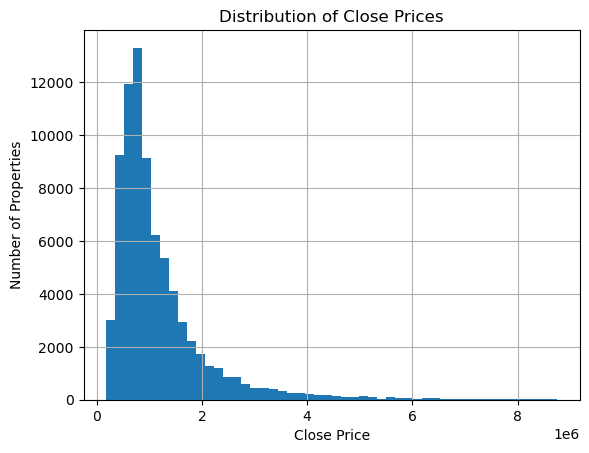

In [ ]:
df_clean["ClosePrice"].hist(bins=50)

plt.title("Distribution of Close Prices")
plt.xlabel("Close Price")
plt.ylabel("Number of Properties")

Text(0, 0.5, 'Number of Properties')

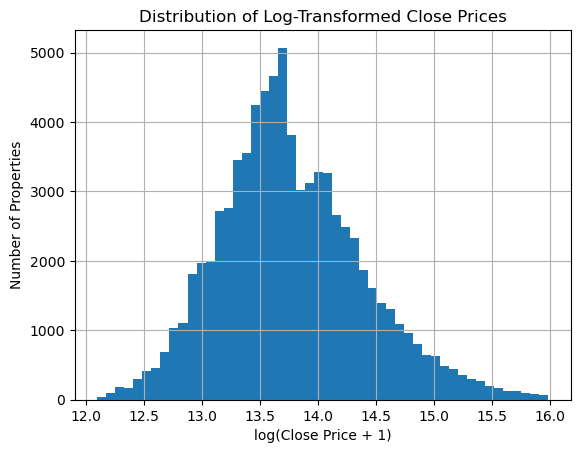

In [ ]:
# Distribution of log-transformed close price
np.log1p(df_clean["ClosePrice"]).hist(bins=50)

plt.title("Distribution of Log-Transformed Close Prices")
plt.xlabel("log(Close Price + 1)")
plt.ylabel("Number of Properties")

Text(0, 0.5, 'Close Price')

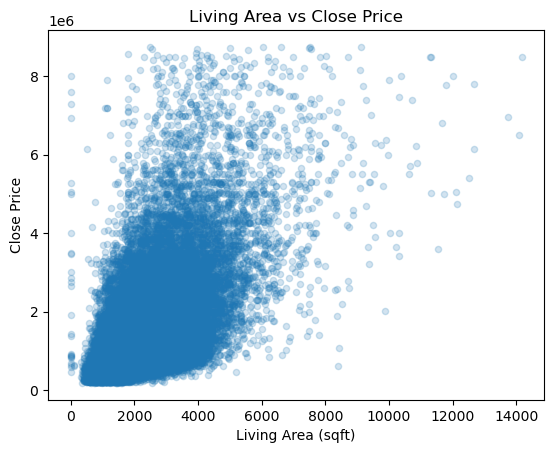

In [ ]:
# Relationship between living area and close price
df_clean.plot.scatter(x="LivingArea", y="ClosePrice", alpha=0.2)

plt.title("Living Area vs Close Price")
plt.xlabel("Living Area (sqft)")
plt.ylabel("Close Price")

Text(0, 0.5, 'Close Price')

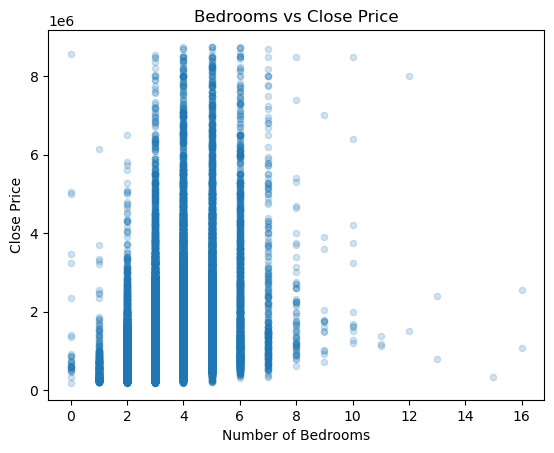

In [ ]:
# Bedrooms vs close price
df_clean.plot.scatter(x="BedroomsTotal", y="ClosePrice", alpha=0.2)

plt.title("Bedrooms vs Close Price")
plt.xlabel("Number of Bedrooms")
plt.ylabel("Close Price")

Text(0, 0.5, 'Close Price')

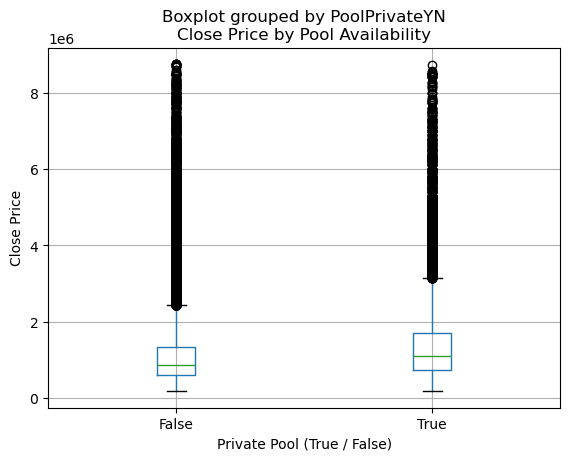

In [ ]:
df_clean.boxplot(column="ClosePrice", by="PoolPrivateYN")

plt.title("Close Price by Pool Availability")
plt.xlabel("Private Pool (True / False)")
plt.ylabel("Close Price")

Text(0, 0.5, 'Close Price')

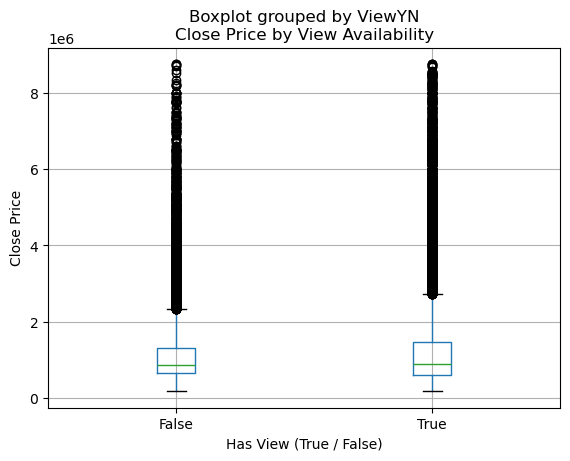

In [ ]:
# Effect of having a view on close price
df_clean.boxplot(column="ClosePrice", by="ViewYN")

plt.title("Close Price by View Availability")
plt.xlabel("Has View (True / False)")
plt.ylabel("Close Price")

In [ ]:
# end - Huiyu Yie (Elsa)